# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** Alishba Amjad  |  **Date:** March,12 2026

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [5]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,5)


## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

# TODO: read_csv with correct separator (\s+) and na_values
df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')

print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** 8 rows and 9 columns

**Q2.** Which column contains missing values and how many?  
**Answer:** _______________


## Task 3 — Pre-Processing

In [6]:
# TODO: Check and print missing values per column
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNaN rows = {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.2f}% of data)")

# Then drop all rows that contain NaN values (they are < 2% of data)
df.dropna(inplace=True)
print("\nAfter dropping NaN rows:", df.shape)

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

NaN rows = 6 (1.51% of data)

After dropping NaN rows: (392, 9)


In [7]:
# TODO: Check for and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [8]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
df['cylinders']   = df['cylinders'].astype('category')
df['model_year']  = df['model_year'].astype('category')
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
df['origin']      = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})

# 3. Strip & lowercase 'car_name'
df['car_name'] = df['car_name'].str.strip().str.lower()
print("Updated dtypes:\n", df.dtypes)



Updated dtypes:
 mpg              float64
cylinders       category
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year      category
origin            object
car_name          object
dtype: object


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    category
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model_year    392 non-null    category
 7   origin        392 non-null    object  
 8   car_name      392 non-null    object  
dtypes: category(2), float64(5), object(2)
memory usage: 26.1+ KB


In [13]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders','origin','model_year']
num_cols = ['mpg','displacement','horsepower','weight','acceleration']
print("Categorical columns:", cat_cols)
print("Numerical columns  :", num_cols)

Categorical columns: ['cylinders', 'origin', 'model_year']
Numerical columns  : ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 4 — Feature Engineering

In [14]:
# TODO: Create 'mpg_level' column using pd.cut()
df['mpg_level'] = pd.cut(df['mpg'],
    # Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'
                          bins=[0, 17, 29, df['mpg'].max()+1],
                          labels=['low','medium','high'],
                          right=False)

In [15]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]

print("New features added:")
print(df[['mpg','mpg_level','car_name','car_company']].head(8))

New features added:
    mpg mpg_level                   car_name car_company
0  18.0    medium  chevrolet chevelle malibu   chevrolet
1  15.0       low          buick skylark 320       buick
2  18.0    medium         plymouth satellite    plymouth
3  16.0       low              amc rebel sst         amc
4  17.0    medium                ford torino        ford
5  15.0       low           ford galaxie 500        ford
6  14.0       low           chevrolet impala   chevrolet
7  14.0       low          plymouth fury iii    plymouth


## Task 5 — Categorical EDA

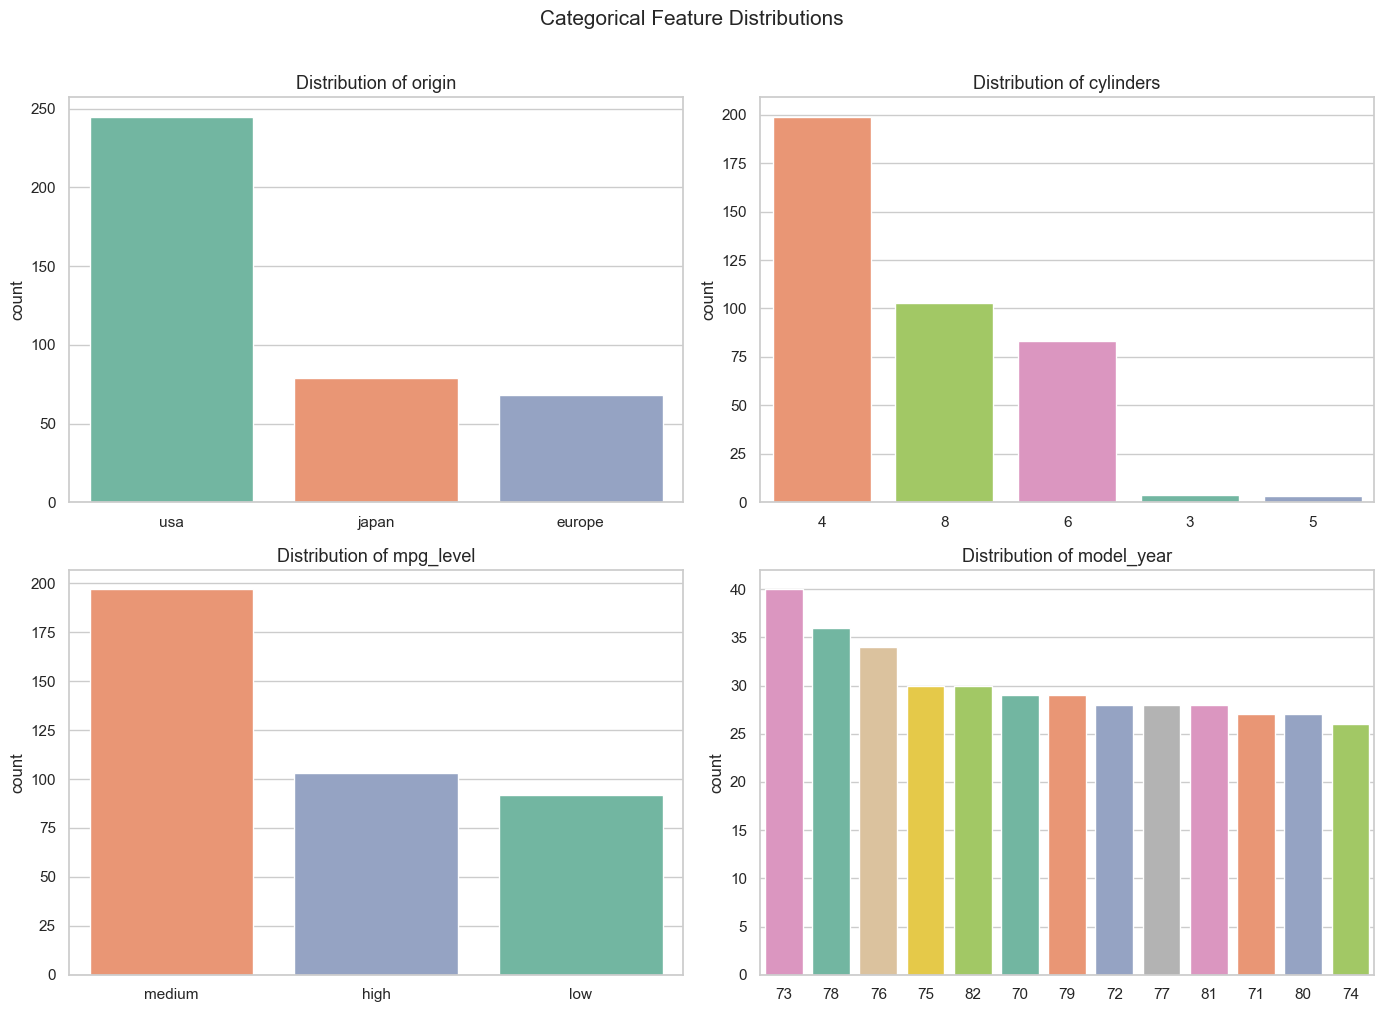

In [20]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_plot_cols = ['origin','cylinders','mpg_level','model_year']

for ax, col in zip(axes.flat, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, hue=col, legend=False,palette='Set2')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel('')

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin','cylinders','mpg_level']:
    top = df[col].value_counts(normalize=True).iloc[0]
    print(f"{col}: dominant class = '{df[col].value_counts().index[0]}' → {top*100:.1f}%")


origin: dominant class = 'usa' → 62.5%
cylinders: dominant class = '4' → 50.8%
mpg_level: dominant class = 'medium' → 50.3%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


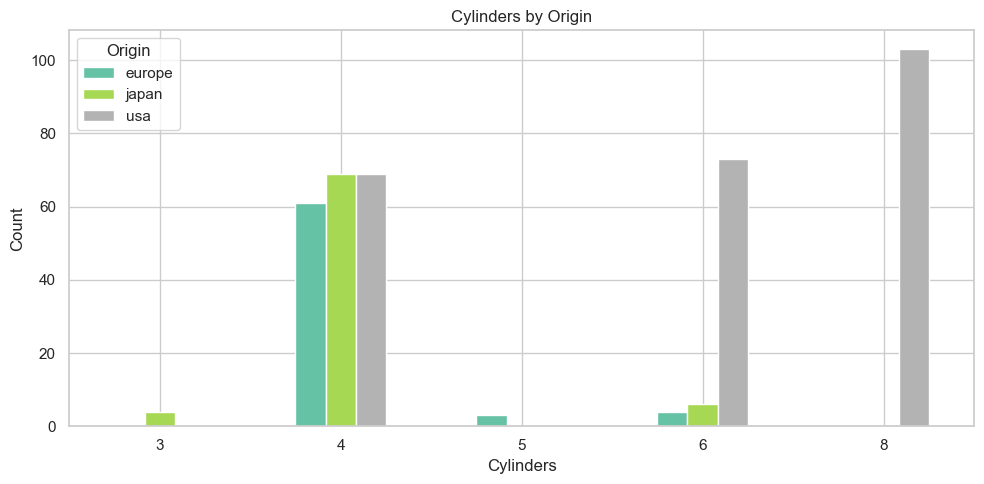

In [21]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
t = pd.crosstab(df['cylinders'], df['origin'])
print(t)

t.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Cylinders by Origin')
plt.xlabel('Cylinders'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.legend(title='Origin')
plt.tight_layout(); plt.show()


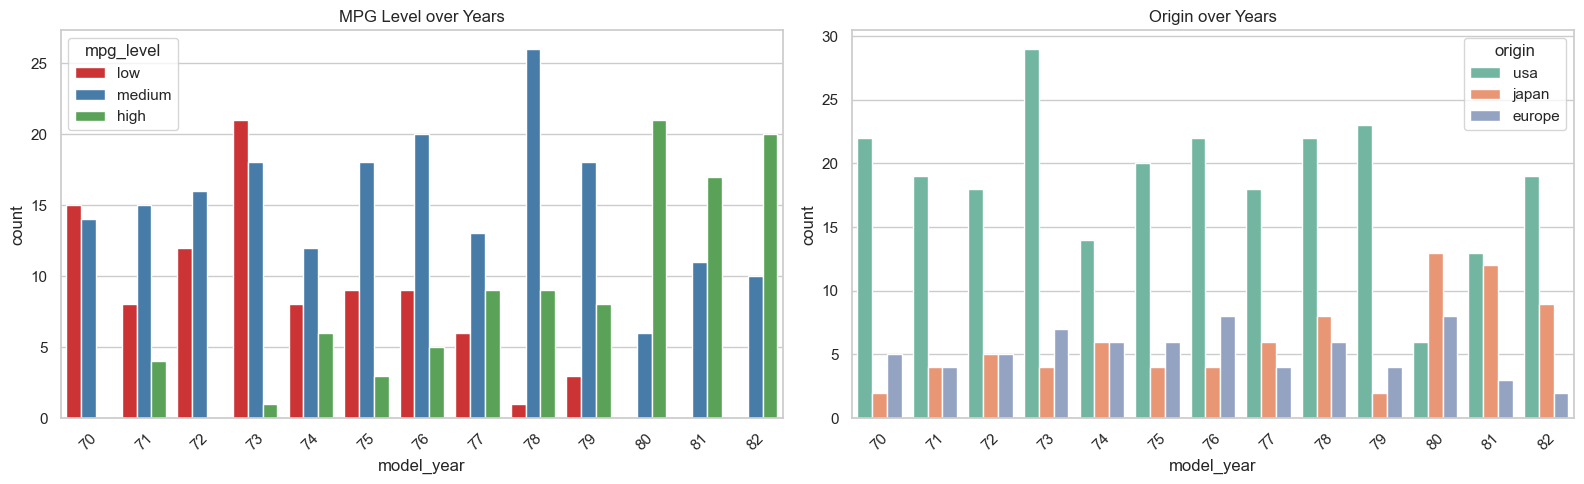

In [19]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# mpg_level vs year
sns.countplot(data=df, x='model_year', hue='mpg_level',
              hue_order=['low','medium','high'],
              palette='Set1', ax=axes[0])
axes[0].set_title('MPG Level over Years')
axes[0].tick_params(axis='x', rotation=45)

# origin vs year
sns.countplot(data=df, x='model_year', hue='origin',
              palette='Set2', ax=axes[1])
axes[1].set_title('Origin over Years')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** Japan (or Europe, depending on your dataset) has no vehicles with low mpg_level.

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** df['cylinders'].value_counts(normalize=True) * 100


## Task 6 — Numerical EDA

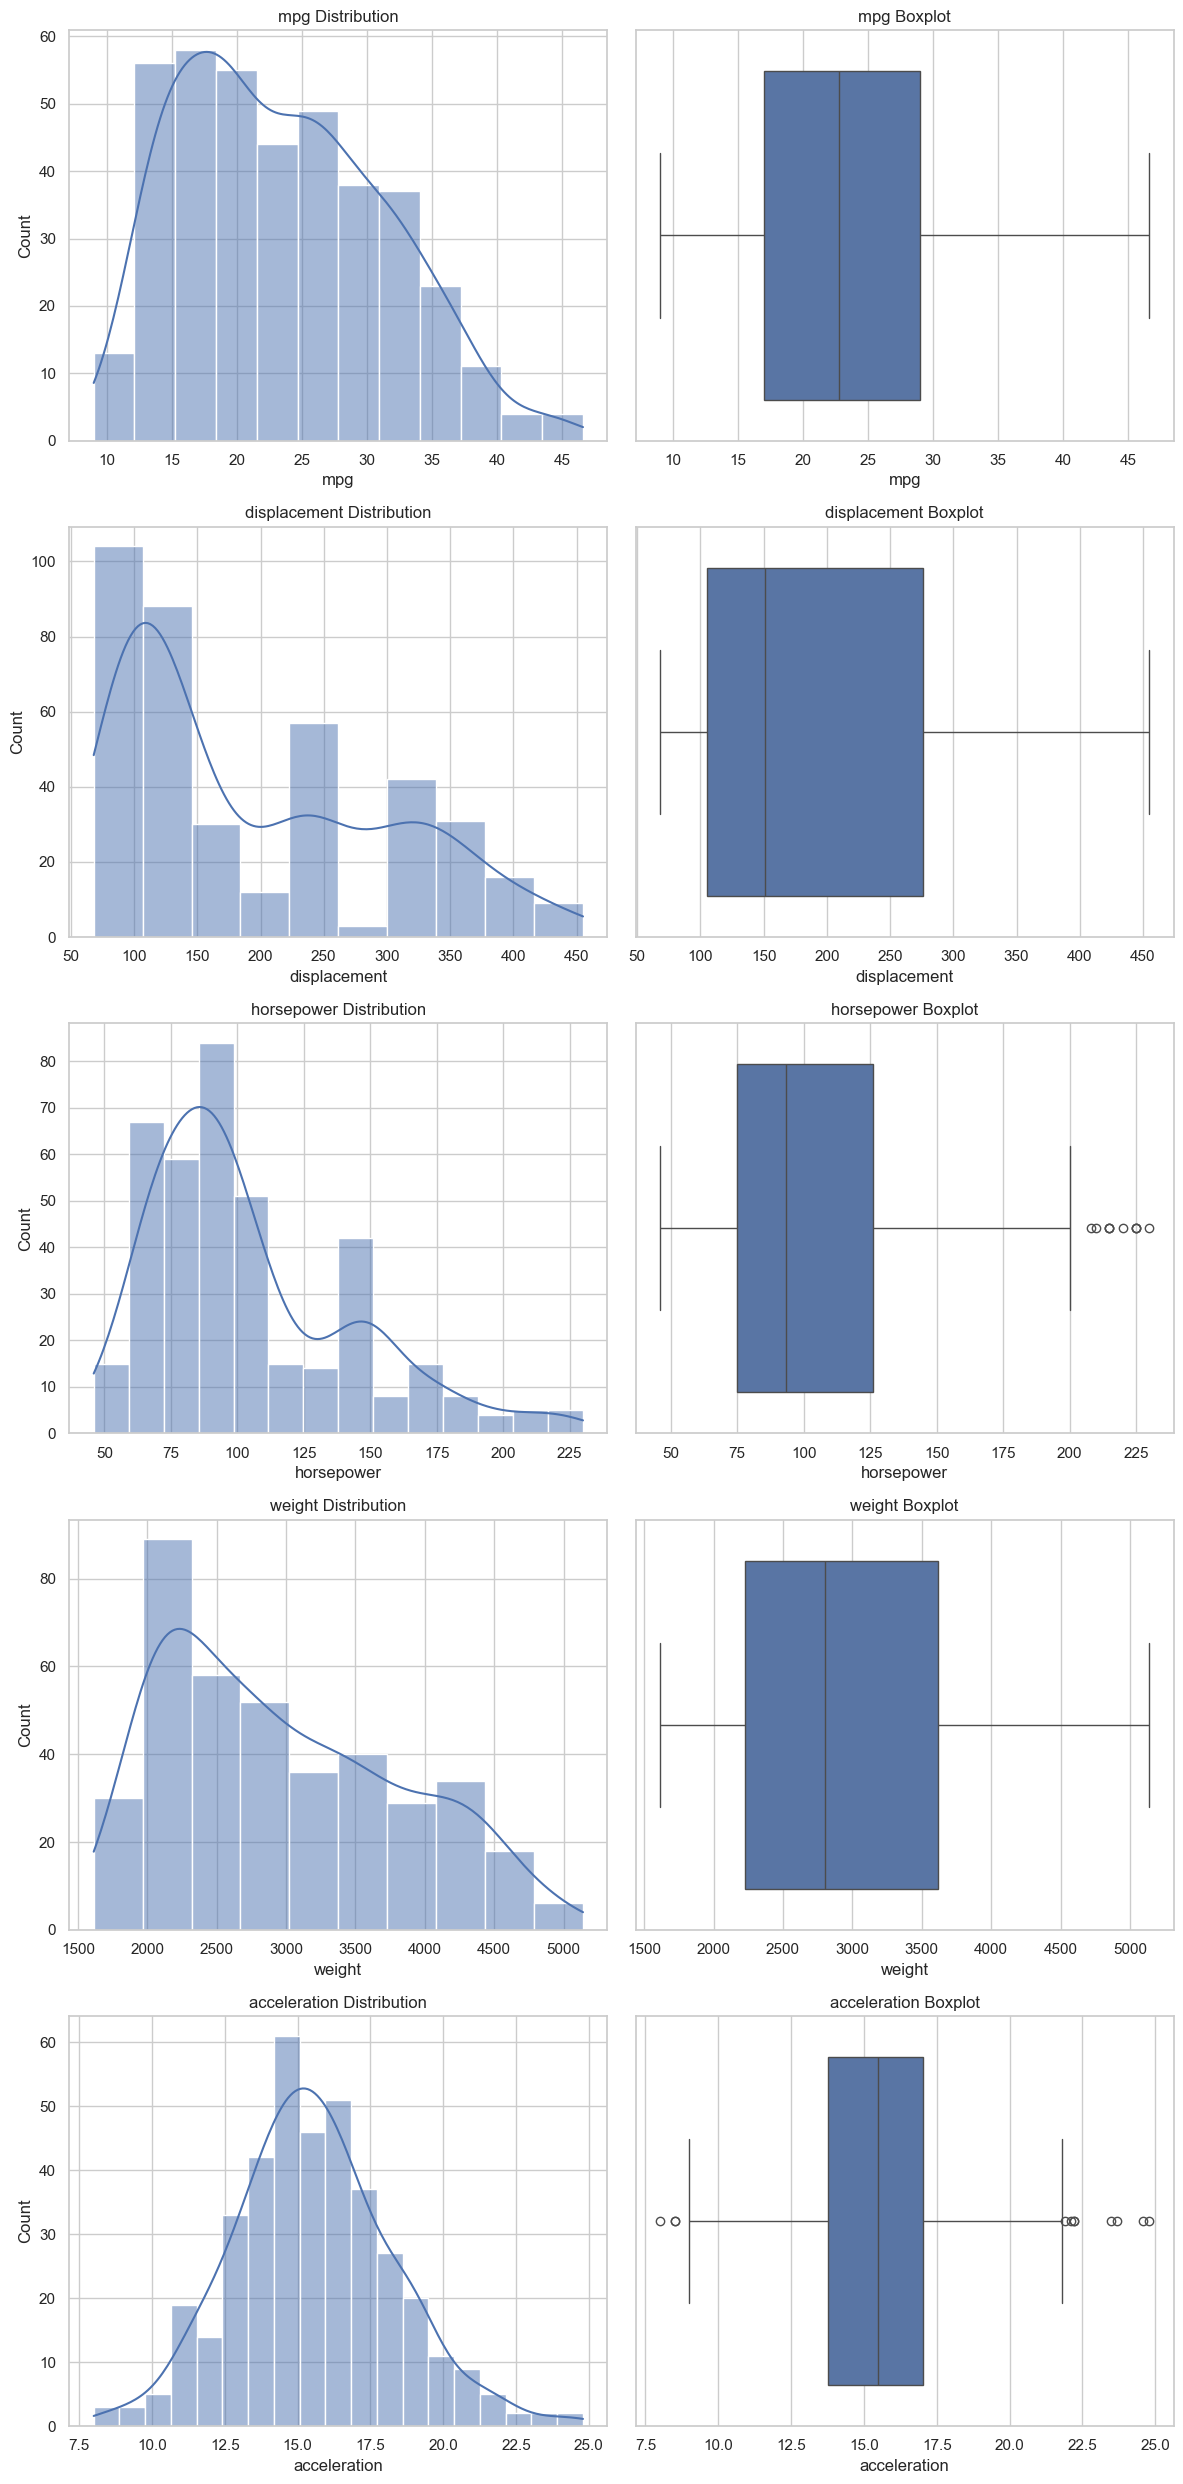

In [22]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns

# Arrange in a grid (n_cols rows × 2 columns)
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 5*len(num_cols)))
for i, col in enumerate(num_cols):
    
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

In [25]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
import numpy as np
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR

def tukey_outliers(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]
    
 # Then print the outlier count for each numerical column    

for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers")

mpg: 0 outliers
displacement: 0 outliers
horsepower: 10 outliers
weight: 0 outliers
acceleration: 11 outliers


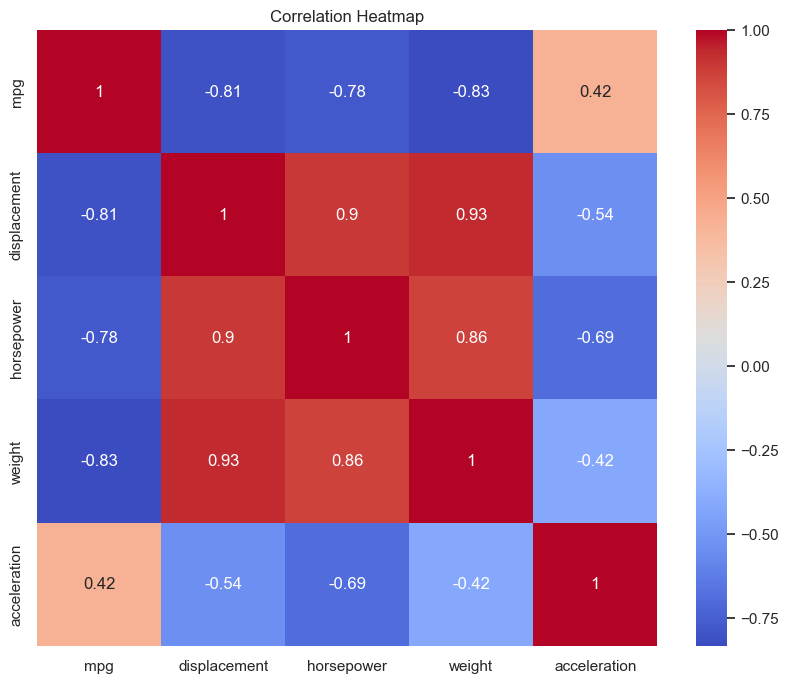

In [26]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


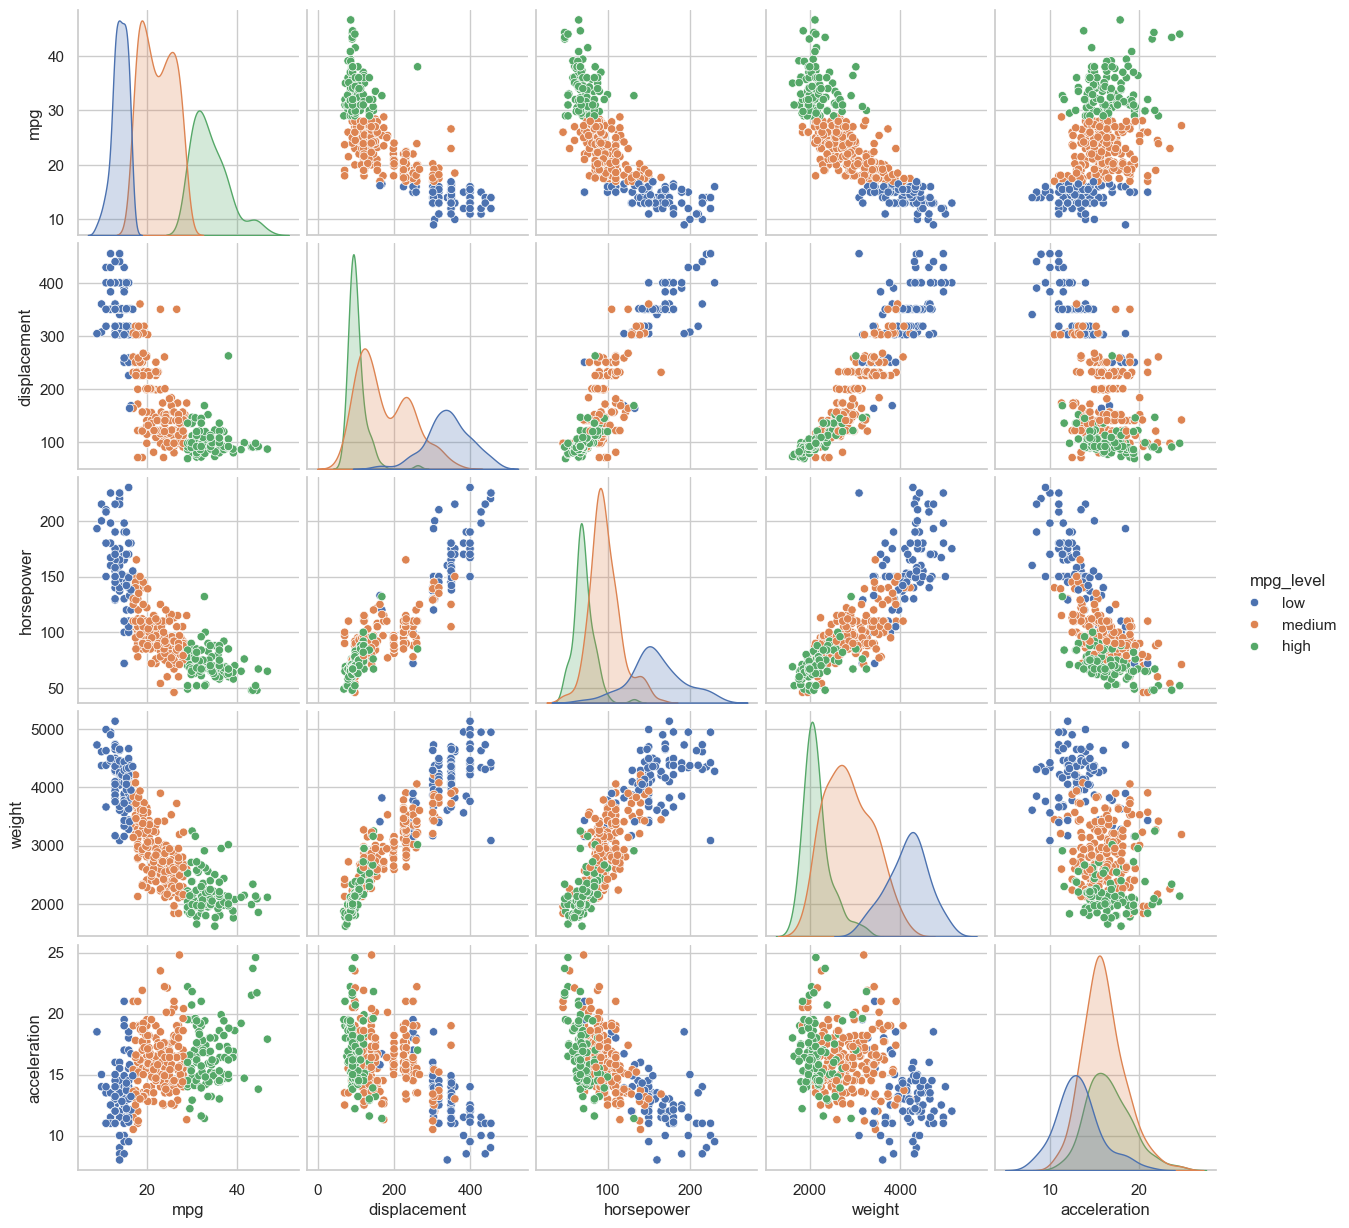

In [27]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df, vars=num_cols, hue='mpg_level')
plt.show()

**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** weight and displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** The acceleration distribution is approximately normal but slightly skewed, as the histogram shows a near bell shape with minor asymmetry.


## Task 7 — Numerical vs Categorical

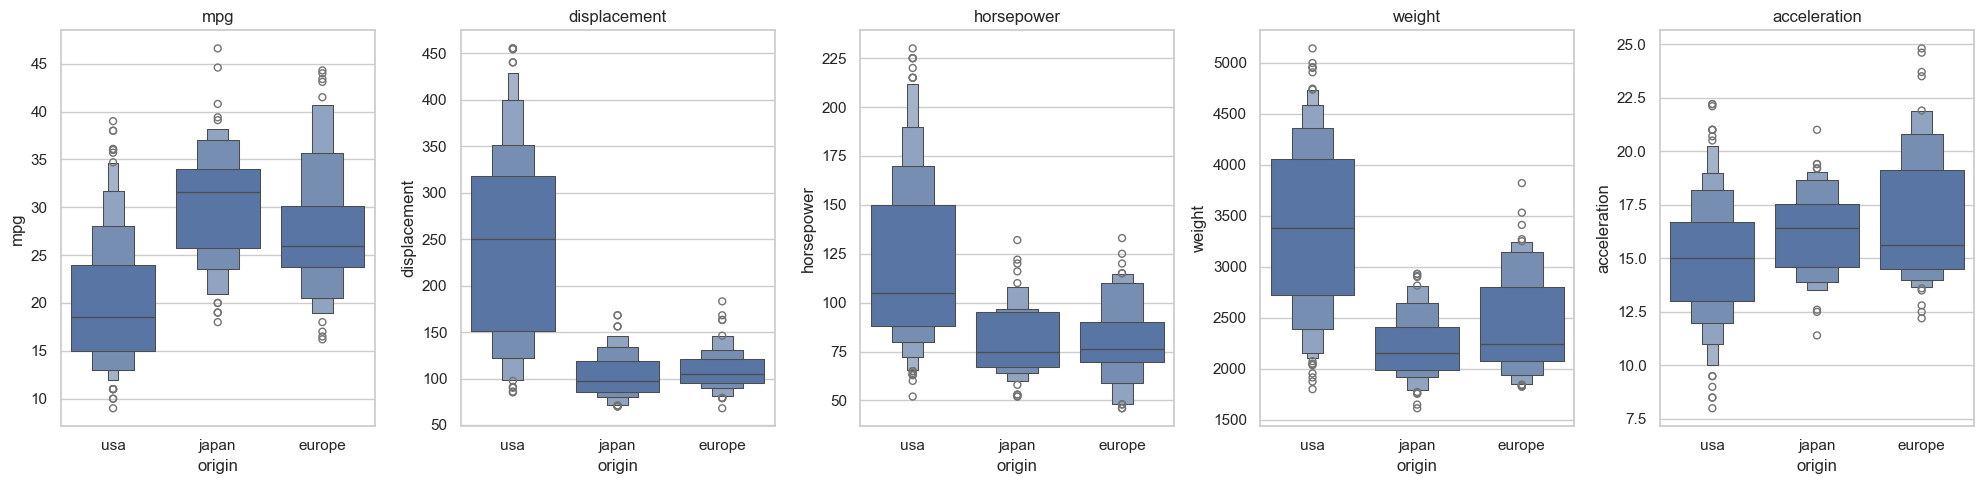

In [28]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)
fig, axes = plt.subplots(1, len(num_cols), figsize=(20,5))

for ax, col in zip(axes, num_cols):
    sns.boxenplot(data=df, x='origin', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


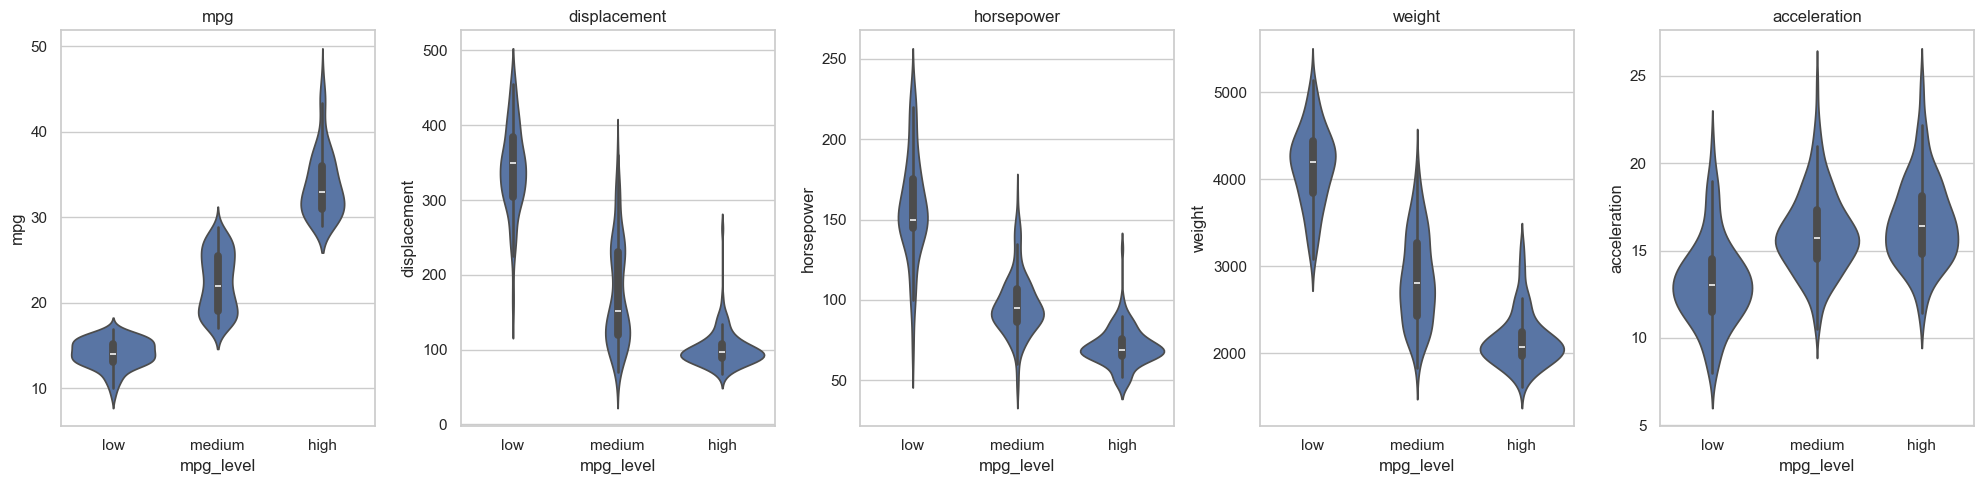

In [29]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'
fig, axes = plt.subplots(1, len(num_cols), figsize=(20,5))

for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


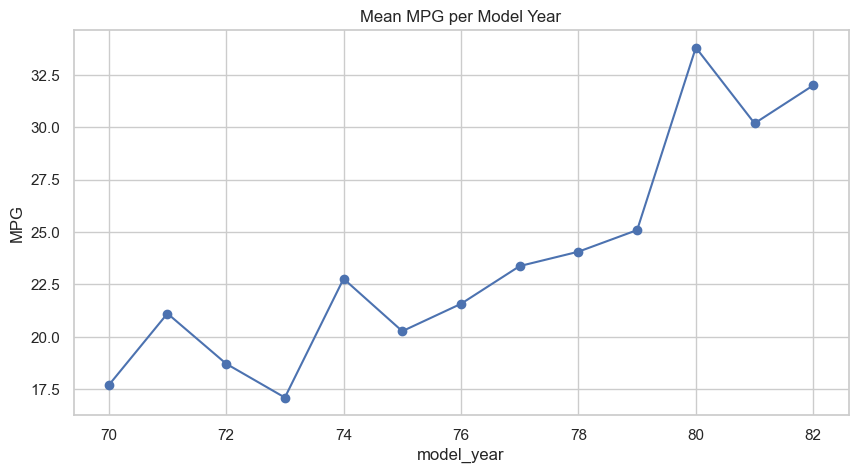

In [33]:
# TODO: Plot a line chart showing mean mpg per model_year
mean_mpg = df.groupby('model_year',observed=False)['mpg'].mean()

plt.figure(figsize=(10,5))
mean_mpg.plot(marker='o')
plt.title('Mean MPG per Model Year')
plt.ylabel('MPG')
plt.show()

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** USA (origin with lowest mpg on average

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** MPG generally increases as model_year increases.


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement |Negative |Strong |
| horsepower |Negative |Strong |
| weight |Negative |Very Strong |
| acceleration |Positive |Weak |
| cylinders |Negative |Strong |
| origin |Varies (Japan/EU higher mpg) |Medium |
| model_year |Positive |Strong |
